# MLMC for Transport

In [1]:
import matplotlib.pyplot as plt
font_size=12
title_size=14
label_size=13
tick_size=11
legend_size=7
dpi=300



plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 7.0,
    "text.usetex": False
})
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]  
sys.path.insert(0, str(PROJECT_ROOT))
project_root = Path("/home/philipp-felsen/Desktop/PyUQFEM")
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd

from fenics import (
    Constant,
    Expression,
    Measure,
    assemble,
    avg,
    dot,
    jump,
)

from fem.transportProblem import Transport

from permeability.lognormalField import LognormalField
from permeability.lognormalInclusion import LognormalInclusion
from permeability.movingInclusion import LognormalMovingInclusion
from permeability.multiphase import MultiphaseField
from permeability.randomShapeField import RandomShapeField

# Energy Assumption

In [3]:
# =============================================================================
# Random-field settings
# =============================================================================
stoch_dim = 15
corr_length = 0.1
mu = 1.0
sigma = 0.25

number_of_phases = 2
phase_values = [2.0, 3.0]

inclusion_values = (2.0, 3.0)
moving_inclusion_value = 3.0

base_seed = 12345


# =============================================================================
# Random-field construction
# =============================================================================

def make_field(field_type):
    if field_type == "LognormalField":
        return LognormalField(
            dim=stoch_dim,
            corrLength=corr_length,
            mu=mu,
            sigma=sigma,
        )

    if field_type == "LognormalInclusion":
        return LognormalInclusion(
            dim=stoch_dim,
            corrLength=corr_length,
            mu=mu,
            sigma=sigma,
            inclusionValues=inclusion_values,
        )

    if field_type == "LognormalMovingInclusion":
        return LognormalMovingInclusion(
            dim=stoch_dim,
            corrLength=corr_length,
            mu=mu,
            sigma=sigma,
            inclusionValue=moving_inclusion_value,
            maxShift=(0.40, 0.40),
        )

    if field_type == "MultiphaseField":
        return MultiphaseField(
            dim=stoch_dim,
            numberOfPhases=number_of_phases,
            phaseValues=phase_values,
            phaseBoundaries=[np.exp(mu)],
            corrLength=corr_length,
            mu=mu,
            sigma=sigma,
        )

    if field_type == "RandomShapeField":
        return RandomShapeField(
            dim=stoch_dim,
            inclusionValue=3.0,
            backgroundValue=2.0,
            center=(0.5, 0.5),
            baseRadius=0.25,
            deformationStrength=0.5,
        )

c0 = Expression(
    """
    x[0] >= x_left &&
    x[0] <= x_right &&
    x[1] >= y_bottom &&
    x[1] <= y_top
    ? c_value : 0.0
    """,
    degree=0,
    x_left=0.125,
    x_right=0.875,
    y_bottom=0.75,
    y_top=0.875,
    c_value=5.0,
)


def make_transport_problem(field, degree, constant_flux=False):
    return Transport(
        permeabilityField=field,
        meshLevelTransport=6,
        degreeTransport=degree,
        c0=c0,
        cInflow=Constant(0.0),
        theta=1.0,                       # implicit Euler
        T=0.5,
        nSteps=100,
        adaptCfl=False,
        storeSolutionHistory=True,
        plotSolution=False,
        analyticFluxConst=constant_flux,
        relTol=1e-12,
        absTol=1e-14,
    )


In [4]:
def quantitites(problem):
    history = problem.solutionHistory
    mesh = problem.mesh

    dx_mesh = Measure("dx", domain=mesh) # Integration over D
    dS_mesh = Measure("dS", domain=mesh) # Integration over interior mesh faces
    ds_mesh = Measure("ds", domain=mesh) # Integration over exterior boundary

    # Normal component of q 
    qn_interior = dot(avg(problem.q), problem.n("+")) # Interior faces
    qn_boundary = dot(problem.q, problem.n) # Boundary faces

    energies = np.array([assemble(c_h * c_h * dx_mesh) for c_h in history]) # Computes ||c_h^n||²_L2

    temporal_dissipation = []
    spatial_dissipation = []
    residuals = []
    relative_residuals = []

    for n in range(len(history) - 1):
        c_old = history[n]
        c_new = history[n + 1]

        # Implicit-Euler temporal dissipation
        d_time = assemble((c_new - c_old) ** 2 * dx_mesh) # ||c_h^n+1 - c_h^n||²_L2

        # Upwind spatial dissipation J(c_new, c_new)
        j_new = assemble(abs(qn_interior) * jump(c_new) ** 2 * dS_mesh + abs(qn_boundary) * c_new**2 * ds_mesh)

        d_space = problem.dt * j_new # Tau * J(...)

        residual = (
            energies[n + 1]
            + d_time
            + d_space
            - energies[n]
        )

        relative_residual = abs(residual) / max(
            abs(energies[n]),
            1e-14,
        )

        relative_residual = abs(residual) / abs(energies[n])

        temporal_dissipation.append(d_time)
        spatial_dissipation.append(d_space)
        residuals.append(residual)
        relative_residuals.append(relative_residual)

    return {
        "energy": energies,
        "temporal_dissipation": np.array(temporal_dissipation),
        "spatial_dissipation": np.array(spatial_dissipation),
        "residual": np.array(residuals),
        "relative_residual": np.array(relative_residuals),
    }

In [5]:
# Calculate
results = {}

degrees = [0, 1]

field_types = [
    "LognormalField",
    "LognormalInclusion",
    "LognormalMovingInclusion",
    "MultiphaseField",
    "RandomShapeField",
]


for degree in degrees:
    print(f"Solving constant flux with p = {degree} ...")

    dummy_field = LognormalField(
        dim=stoch_dim,
        corrLength=corr_length,
        mu=mu,
        sigma=sigma,
    )

    constant_problem = make_transport_problem(
        dummy_field,
        degree=degree,
        constant_flux=True,
    )

    constant_problem.solve(np.zeros(stoch_dim))

    constant_label = rf"constant $q=(0,-1)$, $p={degree}$"

    # Constant-flux result
    results[(degree, "ConstantFlux")] = quantitites(
        constant_problem
    )

    # -------------------------------------------------------------------------
    # Random-field problems
    # -------------------------------------------------------------------------

    for field_number, field_type in enumerate(field_types):
        print(f"Solving {field_type} with p = {degree} ...")

        field = make_field(field_type)

        rng = np.random.default_rng(
            base_seed + field_number
        )

        xi = rng.uniform(
            -1.0,
            1.0,
            size=stoch_dim,
        )

        problem = make_transport_problem(
            field,
            degree=degree,
            constant_flux=False,
        )

        problem.solve(xi)

        label = rf"{field_type}, $p={degree}$"

        results[(degree, field_type)] = quantitites(
            problem
        )


Solving constant flux with p = 0 ...
Solving LognormalField with p = 0 ...
Solving LognormalInclusion with p = 0 ...
Solving LognormalMovingInclusion with p = 0 ...
Solving MultiphaseField with p = 0 ...
Solving RandomShapeField with p = 0 ...
Solving constant flux with p = 1 ...
Solving LognormalField with p = 1 ...
Solving LognormalInclusion with p = 1 ...
Solving LognormalMovingInclusion with p = 1 ...
Solving MultiphaseField with p = 1 ...
Solving RandomShapeField with p = 1 ...


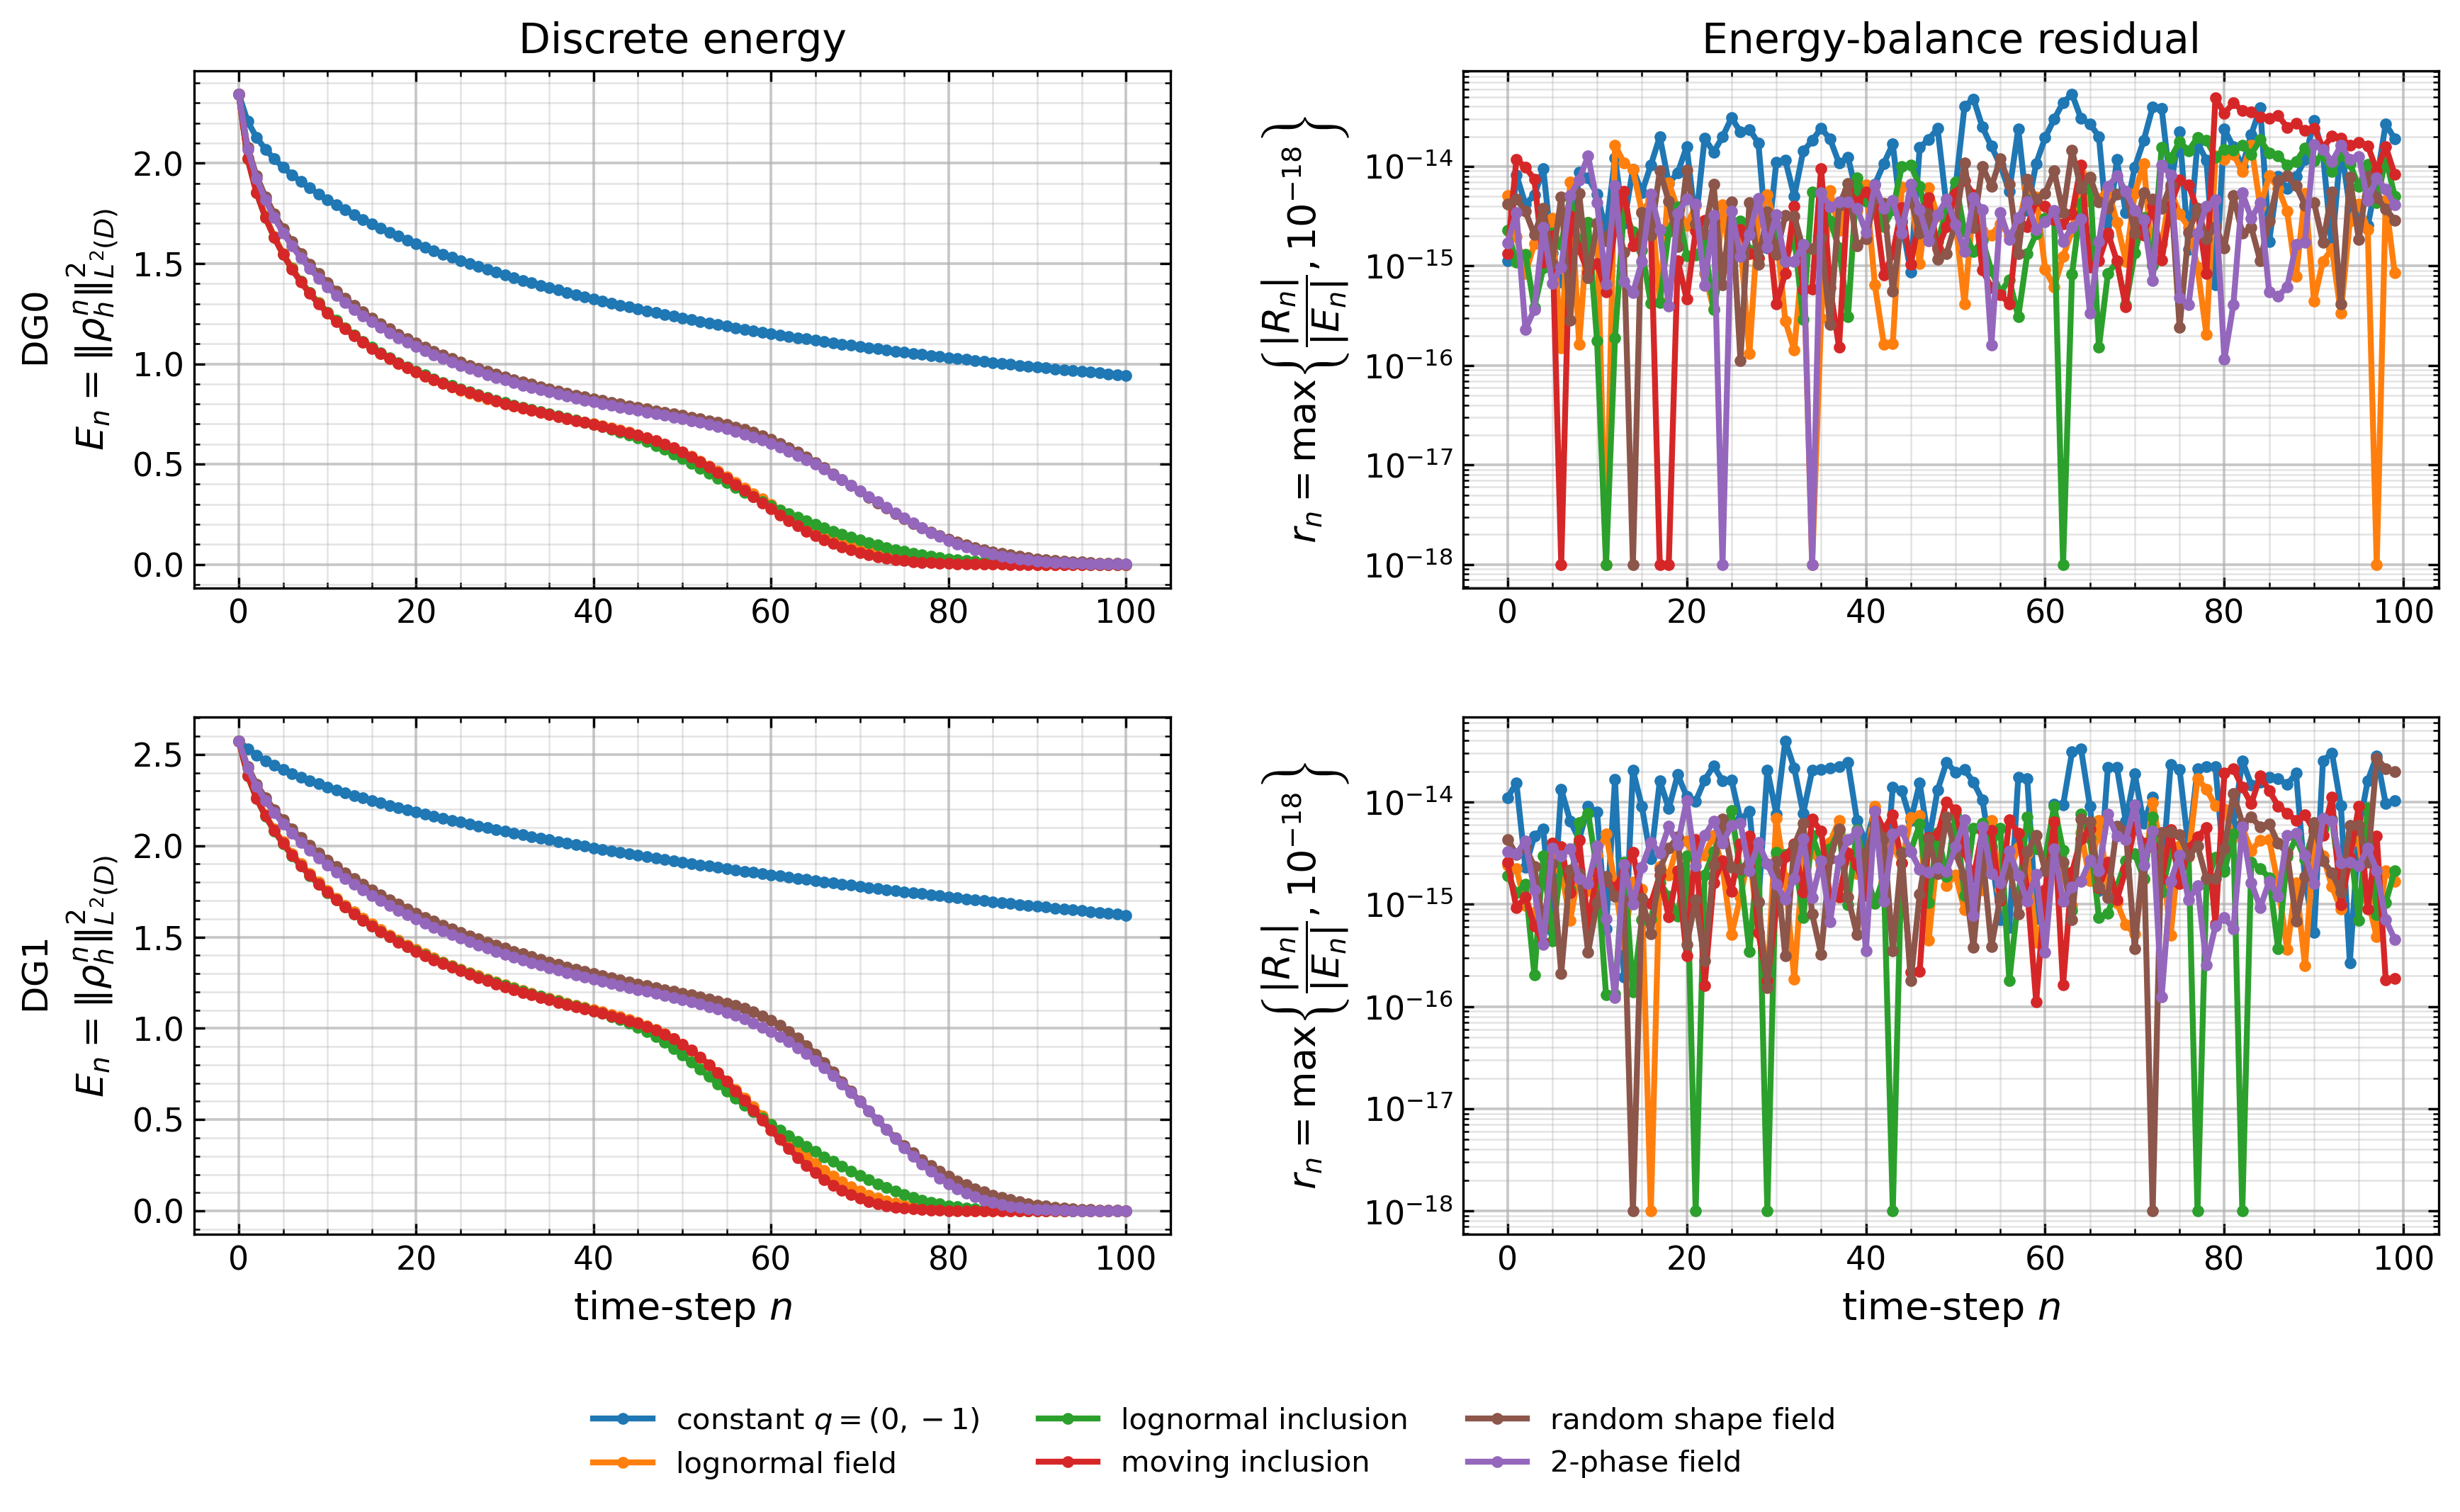

In [6]:
def plot_energy_results(
    results,
    degrees=(0, 1),
):
    field_types = [
        "ConstantFlux",
        "LognormalField",
        "LognormalInclusion",
        "LognormalMovingInclusion",
        "RandomShapeField",
        "MultiphaseField"
    ]

    field_labels = {
        "ConstantFlux": r"constant $q=(0,-1)$",
        "LognormalField": "lognormal field",
        "LognormalInclusion": "lognormal inclusion",
        "LognormalMovingInclusion": "moving inclusion",
        "MultiphaseField": "2-phase field",
        "RandomShapeField": "random shape field",
    }

    field_styles = {
        "ConstantFlux": dict(
            color="C0",
            marker="o",
            linestyle="-",
        ),
        "LognormalField": dict(
            color="C1",
            marker="o",
            linestyle="-",
        ),
        "LognormalInclusion": dict(
            color="C2",
            marker="o",
            linestyle="-",
        ),
        "LognormalMovingInclusion": dict(
            color="C3",
            marker="o",
            linestyle="-",
        ),
        "MultiphaseField": dict(
            color="C4",
            marker="o",
            linestyle="-",
        ),
        "RandomShapeField": dict(
            color="C5",
            marker="o",
            linestyle="-",
        ),
    }

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12.0, 7.5),
        sharex=False,
        constrained_layout=False,
    )

    for row, degree in enumerate(degrees):
        energy_ax = axes[row, 0]
        residual_ax = axes[row, 1]

        for field_type in field_types:
            key = (degree, field_type)

            if key not in results:
                print(
                    f"Warning: no result for "
                    f"{field_type}, p={degree}"
                )
                continue

            data = results[key]
            energies = data["energy"]

            energy_steps = np.arange(len(energies))

            energy_ax.plot(
                energy_steps,
                energies,
                label=field_labels.get(
                    field_type,
                    field_type,
                ),
                markersize=3,
                **field_styles[field_type],
            )

            relative_residuals = np.maximum(
                data["relative_residual"],
                1e-18,
            )


            residual_steps = np.arange(
                len(relative_residuals)
            )

            residual_ax.semilogy(
                residual_steps,
                relative_residuals,
                label=field_labels.get(
                    field_type,
                    field_type,
                ),
                markersize=3,
                **field_styles[field_type],
            )

        # Row label
        energy_ax.text(
            -0.16,
            0.5,
            rf"DG${degree}$",
            transform=energy_ax.transAxes,
            rotation=90,
            horizontalalignment="center",
            verticalalignment="center",
        )

        energy_ax.set_ylabel(
            r"$E_n=\|\rho_h^n\|_{L^2(D)}^2$"
        )


        residual_ax.set_ylabel(
            r"$r_n=\dfrac{|R_n|}{|E_n|}$"
        )
        residual_ax.set_ylabel(
            r"$r_n="
            r"\max\left\{"
            r"\dfrac{|R_n|}{|E_n|},"
            r"10^{-18}"
            r"\right\}$"
        )

        for ax in (energy_ax, residual_ax):
            ax.grid(
                True,
                which="major",
                linewidth=0.9,
                alpha=0.7,
            )
            ax.grid(
                True,
                which="minor",
                linewidth=0.6,
                alpha=0.35,
            )
            ax.tick_params(
                which="both",
                direction="in",
                top=True,
                right=True,
            )
            ax.minorticks_on()

    axes[0, 0].set_title("Discrete energy")
    axes[0, 1].set_title("Energy-balance residual")

    axes[1, 0].set_xlabel(r"time-step $n$")
    axes[1, 1].set_xlabel(r"time-step $n$")

    # Collect unique legend entries from all subplots
    handles = []
    labels = []

    for ax in axes.ravel():
        h, l = ax.get_legend_handles_labels()

        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=3,
        frameon=False,
        fontsize=10
    )


    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.91,
        bottom=0.18,
        wspace=0.30,
        hspace=0.25,
    )

    plt.show()

plot_energy_results(
    results,
    degrees=(0, 1),
)

# MLMC assumptions verification

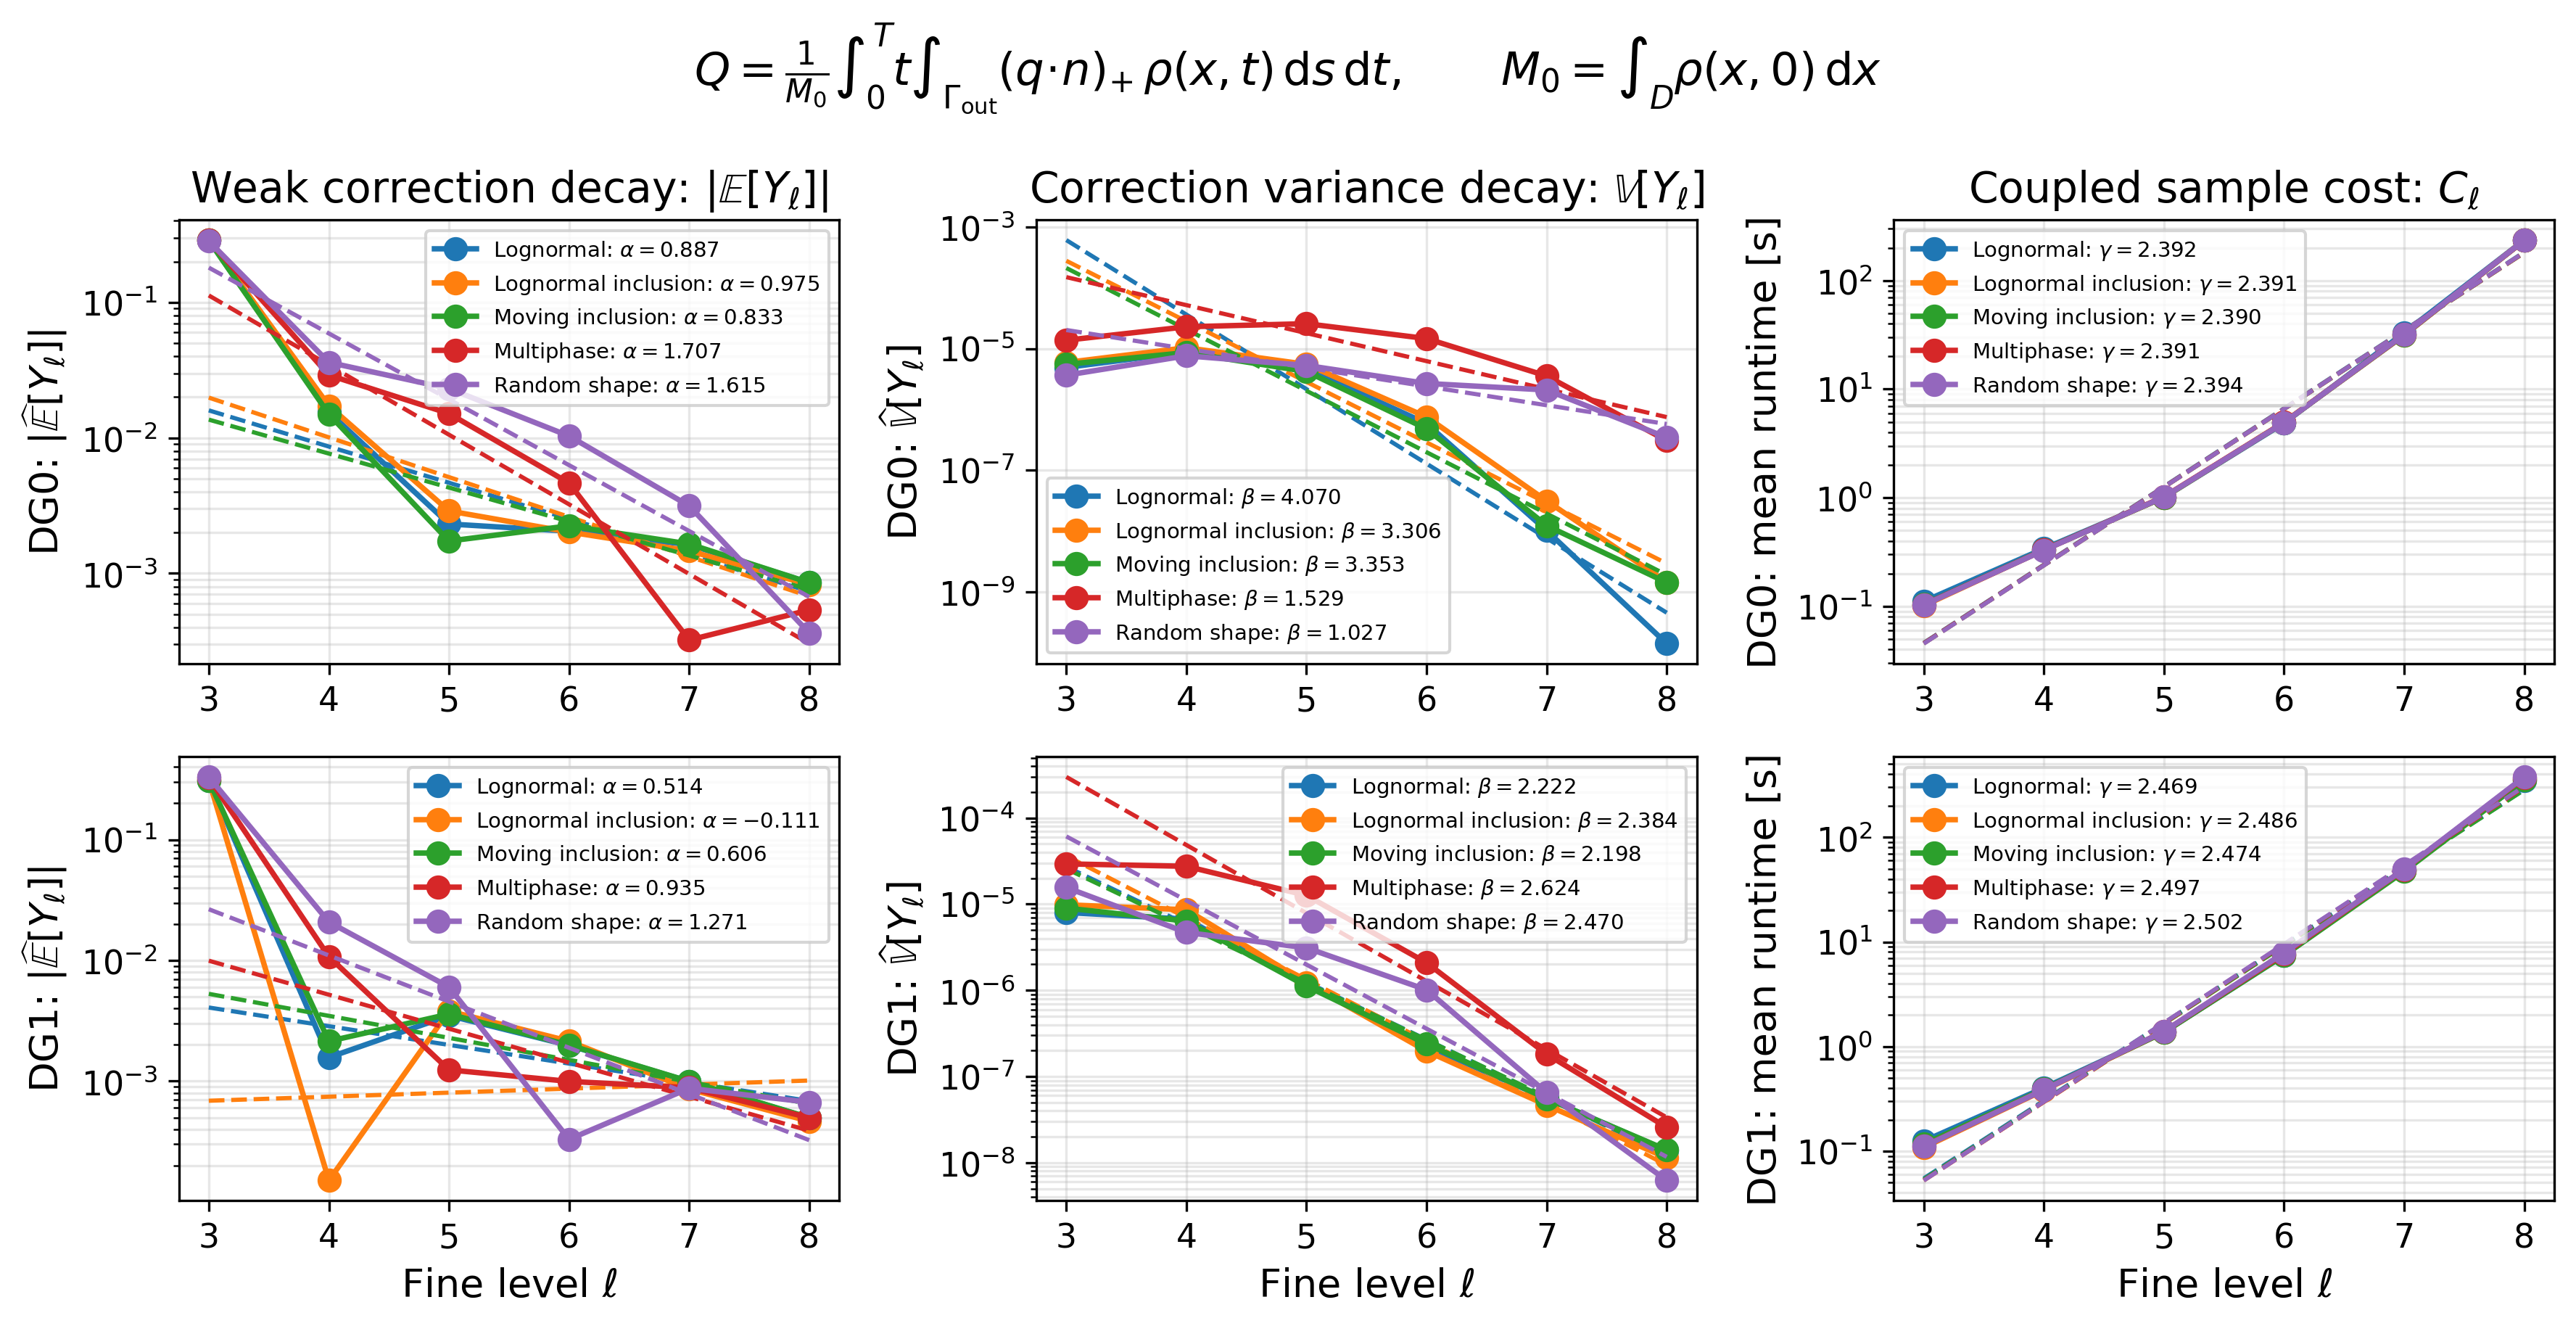

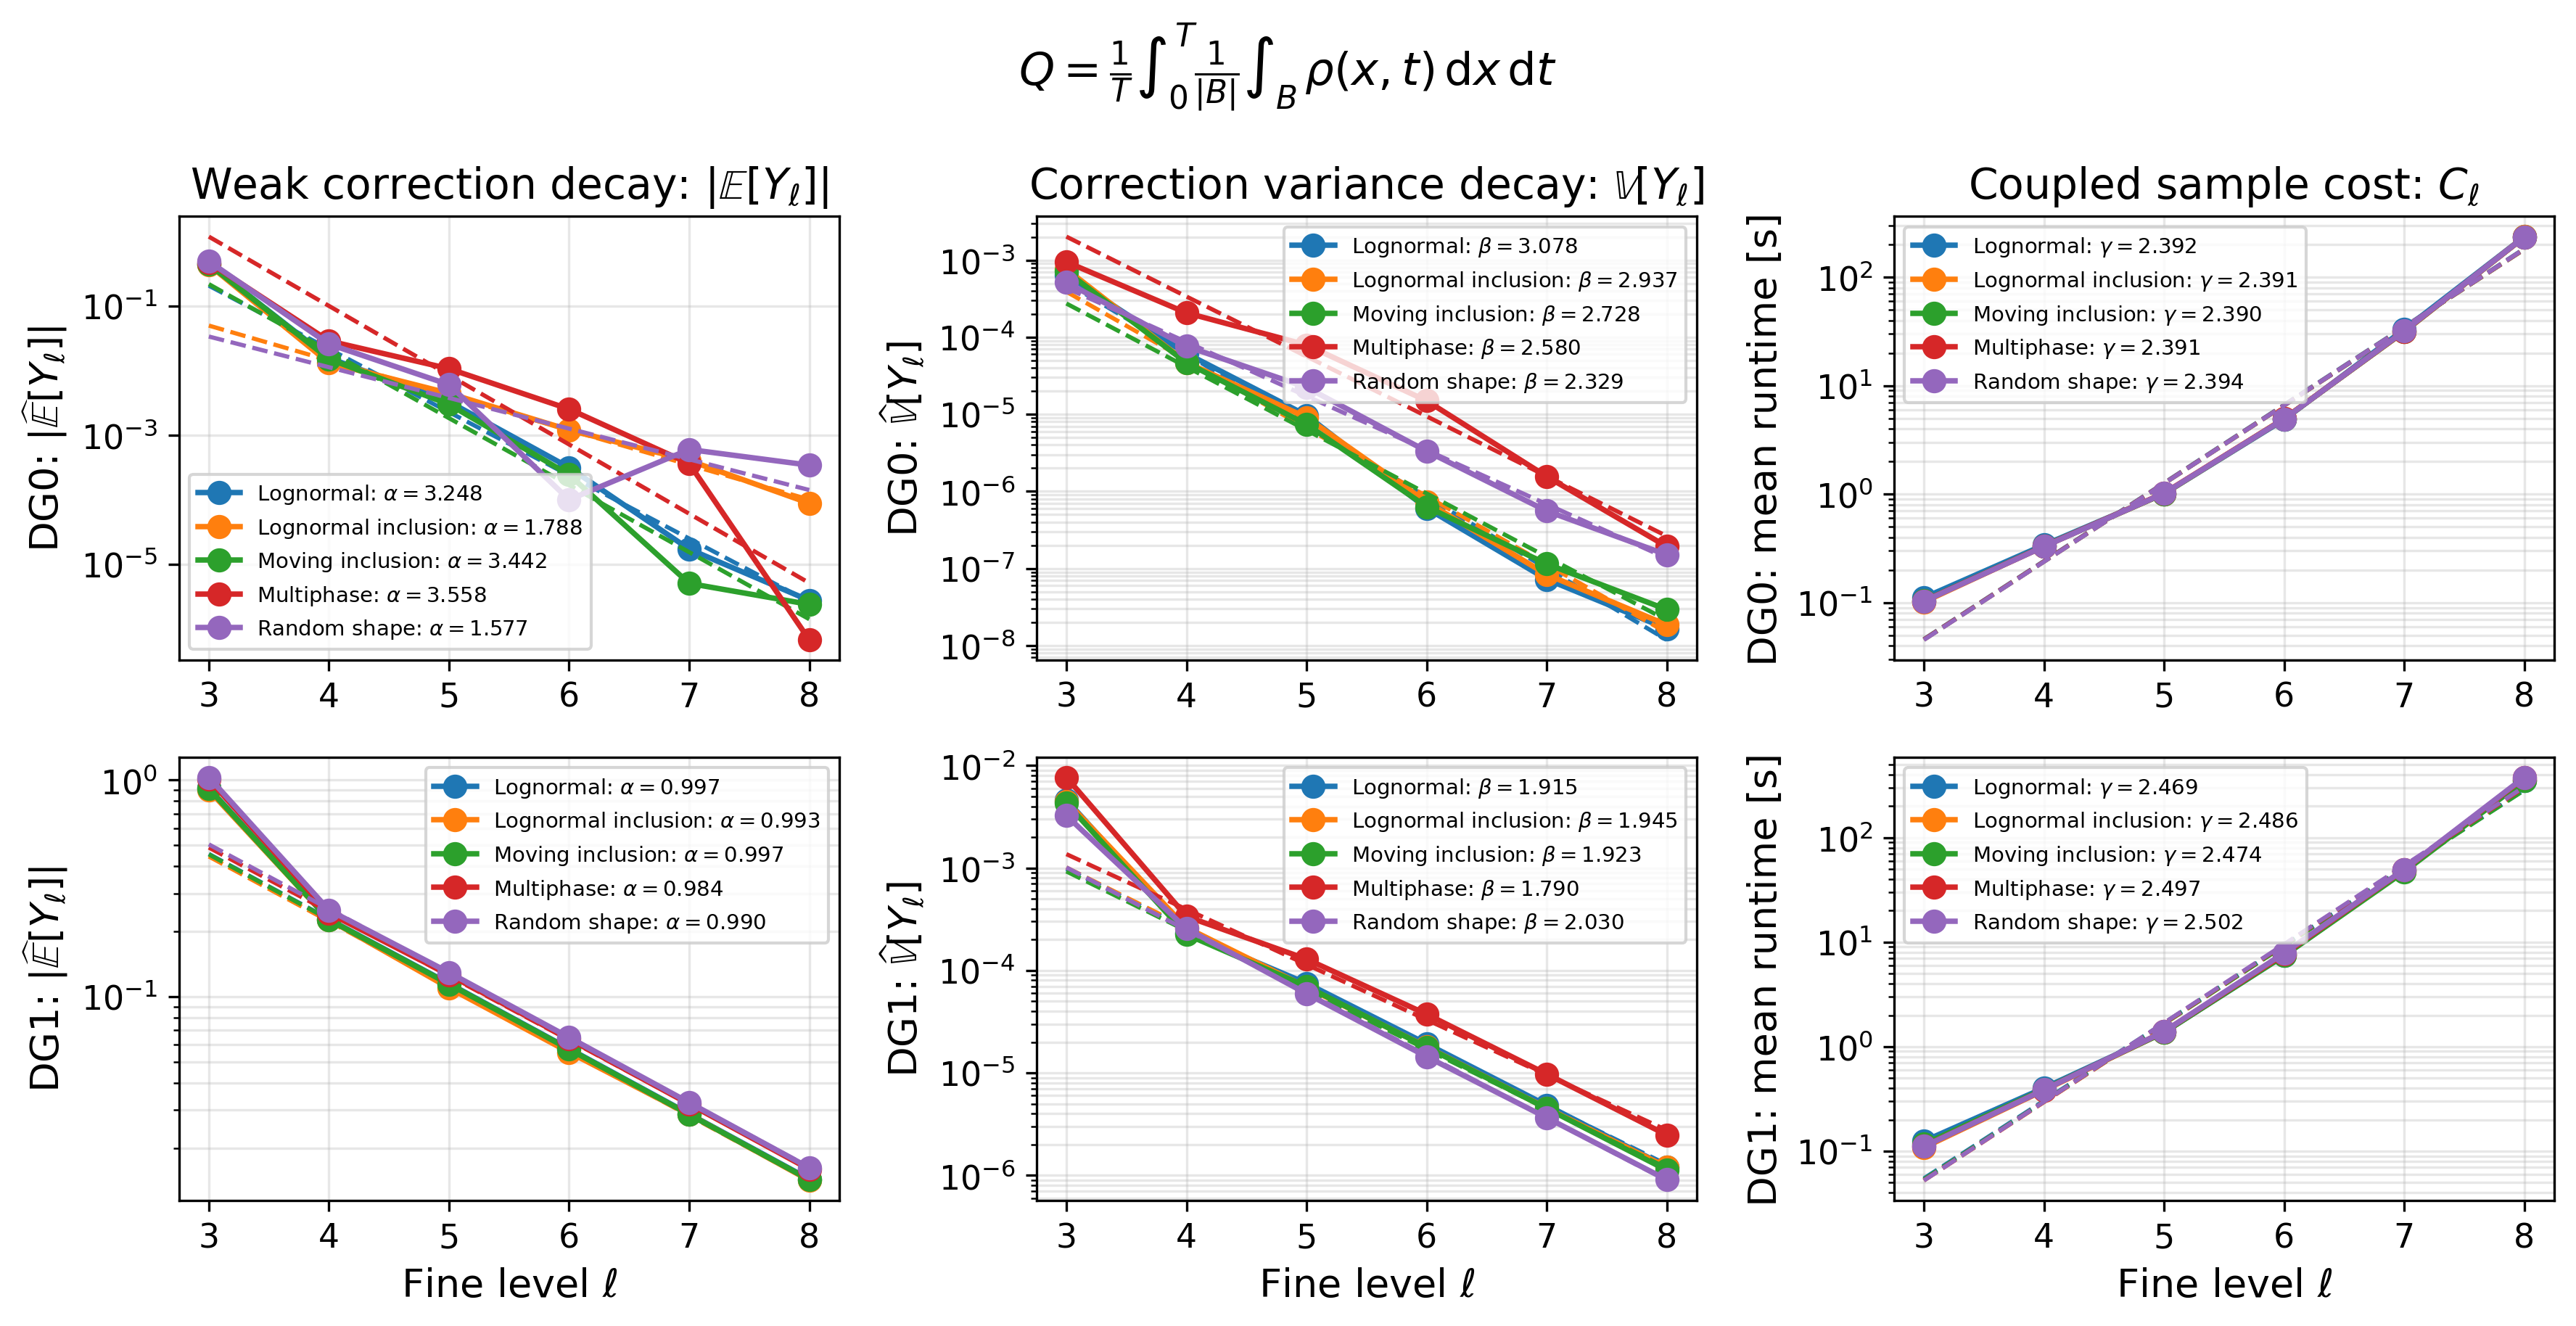

In [3]:

# =============================================================================
# Settings
# =============================================================================

data_file = Path("pklData/mlmc_verification.pkl")

qois_to_plot = [
    "outflow_first_moment_normalized",
    "mean_c_box_time_average"]

qoi_latex_titles = {
    "outflow_first_moment_normalized": (
        r"$Q=\frac{1}{M_0}\int_0^T t"
        r"\int_{\Gamma_{\mathrm{out}}}"
        r"(q\!\cdot\!n)_{+}\,\rho(x,t)"
        r"\,\mathrm{d}s\,\mathrm{d}t,"
        r"\qquad M_0=\int_D\rho(x,0)\,\mathrm{d}x$"
    ),
    "mean_c_box_time_average": (
        r"$Q=\frac{1}{T}\int_0^T\frac{1}{|B|}"
        r"\int_B \, \rho(x,t)\,\mathrm{d}x\,\mathrm{d}t$"
    ),
    "L2normSquared": (
        r"$Q=\int_0^T\int_D\rho(x,t)^2"
        r"\,\mathrm{d}x\,\mathrm{d}t$"
    ),
}

fit_levels = [4, 5, 6, 7, 8]


field_name_labels = {
    "LognormalField": "Lognormal",
    "LognormalInclusion": "Lognormal inclusion",
    "LognormalMovingInclusion": "Moving inclusion",
    "RandomShapeField": "Random shape",
    "MultiphaseField": "Multiphase",
}


# =============================================================================
# Load raw sample dataframe
# =============================================================================

df = pd.read_pickle(data_file)
base_level = int(df["mlmc_level"].min())


required_columns = [
    "field_type",
    "degree_transport",
    "mlmc_level",
    "coupled_runtime",
    *[f"delta_{qoi}" for qoi in qois_to_plot],
]



# =============================================================================
# Regression helpers
# =============================================================================

def fit_power_law(levels, values, sign):
    levels = np.asarray(levels, dtype=float)
    values = np.asarray(values, dtype=float)

    valid = np.isfinite(levels) & np.isfinite(values) & (values > 0.0)
    x = levels[valid]
    y_values = values[valid]

    if len(x) < 2:
        return np.nan, np.nan

    y = np.log2(y_values)
    slope, intercept = np.polyfit(x, y, 1)
    exponent = sign * slope

    fitted_y = intercept + slope * x
    residual_sum = np.sum((y - fitted_y) ** 2)
    total_sum = np.sum((y - np.mean(y)) ** 2)

    r_squared = (
        1.0 - residual_sum / total_sum
        if total_sum > 0.0
        else np.nan
    )

    return exponent, r_squared


def fitted_over_all_levels(fit_levels_array, fit_values, all_levels):
    fit_levels_array = np.asarray(fit_levels_array, dtype=float)
    fit_values = np.asarray(fit_values, dtype=float)
    all_levels = np.asarray(all_levels, dtype=float)

    valid = (
        np.isfinite(fit_levels_array)
        & np.isfinite(fit_values)
        & (fit_values > 0.0)
    )

    if np.count_nonzero(valid) < 2:
        return np.full_like(all_levels, np.nan, dtype=float)

    slope, intercept = np.polyfit(
        fit_levels_array[valid],
        np.log2(fit_values[valid]),
        1,
    )

    return 2.0 ** (intercept + slope * all_levels)


# =============================================================================
# Calculate statistics and produce one figure per QoI
# =============================================================================

exponent_rows = []
degrees = [0, 1]

for qoi in qois_to_plot:
    summary_rows = []

    for (field_type, degree, level), group in df.groupby(
        ["field_type", "degree_transport", "mlmc_level"]
    ):  
        # Skip level 1
        if level < 2:
            continue
        delta = group[f"delta_{qoi}"].to_numpy(dtype=float)
        delta = delta[np.isfinite(delta)]

        fine_cost = group["fine_runtime"].to_numpy(dtype=float)
        coarse_cost = group["coarse_runtime"].to_numpy(dtype=float)

        if int(level) == base_level:
            costs = fine_cost
        else:
            costs = fine_cost + coarse_cost

        costs = costs[np.isfinite(costs)]

        if len(delta) == 0:
            continue

        mean_delta = np.mean(delta)
        variance_delta = np.var(delta, ddof=1) if len(delta) > 1 else np.nan

        summary_rows.append(
            {
                "field_type": field_type,
                "degree_transport": int(degree),
                "mlmc_level": int(level),
                "n_samples": len(delta),
                "mean_delta": mean_delta,
                "abs_mean_delta": abs(mean_delta),
                "variance_delta": variance_delta,
                "mean_cost": np.mean(costs) if len(costs) > 0 else np.nan,
            }
        )

    summary = (
        pd.DataFrame(summary_rows)
        .sort_values(["degree_transport", "field_type", "mlmc_level"])
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(12.0, 6.2),
    )

    for row, degree in enumerate(degrees):
        degree_data = summary[summary["degree_transport"] == degree]

        if degree_data.empty:
            for axis in axes[row, :]:
                axis.set_visible(False)
            continue

        field_types = sorted(degree_data["field_type"].unique())
        alpha_axis, beta_axis, gamma_axis = axes[row, :]

        for field_type in field_types:
            field_data = degree_data[
                degree_data["field_type"] == field_type
            ].sort_values("mlmc_level")

            levels = field_data["mlmc_level"].to_numpy(dtype=float)
            mean_values = field_data["abs_mean_delta"].to_numpy(dtype=float)
            variance_values = field_data["variance_delta"].to_numpy(dtype=float)
            cost_values = field_data["mean_cost"].to_numpy(dtype=float)

            fit_mask = np.isin(levels, fit_levels)
            fit_x = levels[fit_mask]
            fit_mean = mean_values[fit_mask]
            fit_variance = variance_values[fit_mask]
            fit_cost = cost_values[fit_mask]

            alpha, alpha_r2 = fit_power_law(fit_x, fit_mean, sign=-1)
            beta, beta_r2 = fit_power_law(fit_x, fit_variance, sign=-1)
            gamma, gamma_r2 = fit_power_law(fit_x, fit_cost, sign=1)

            fitted_mean_all = fitted_over_all_levels(fit_x, fit_mean, levels)
            fitted_variance_all = fitted_over_all_levels(
                fit_x, fit_variance, levels
            )
            fitted_cost_all = fitted_over_all_levels(fit_x, fit_cost, levels)

            label = field_name_labels.get(field_type, field_type)

            alpha_line, = alpha_axis.semilogy(
                levels,
                mean_values,
                marker="o",
                linewidth=1.8,
                label=rf"{label}: $\alpha={alpha:.3f}$",
            )
            alpha_axis.semilogy(
                levels,
                fitted_mean_all,
                linestyle="--",
                linewidth=1.4,
                color=alpha_line.get_color(),
            )

            beta_line, = beta_axis.semilogy(
                levels,
                variance_values,
                marker="o",
                linewidth=1.8,
                label=rf"{label}: $\beta={beta:.3f}$",
            )
            beta_axis.semilogy(
                levels,
                fitted_variance_all,
                linestyle="--",
                linewidth=1.4,
                color=beta_line.get_color(),
            )

            gamma_line, = gamma_axis.semilogy(
                levels,
                cost_values,
                marker="o",
                linewidth=1.8,
                label=rf"{label}: $\gamma={gamma:.3f}$",
            )
            gamma_axis.semilogy(
                levels,
                fitted_cost_all,
                linestyle="--",
                linewidth=1.4,
                color=gamma_line.get_color(),
            )

            exponent_rows.append(
                {
                    "degree_transport": degree,
                    "field_type": field_type,
                    "qoi": qoi,
                    "alpha": alpha,
                    "alpha_R2": alpha_r2,
                    "beta": beta,
                    "beta_R2": beta_r2,
                    "gamma": gamma,
                    "gamma_R2": gamma_r2,
                }
            )

        alpha_axis.set_ylabel(
            rf"DG{degree}: $|\widehat{{\mathbb{{E}}}}[Y_\ell]|$"
        )
        beta_axis.set_ylabel(
            rf"DG{degree}: $\widehat{{\mathbb{{V}}}}[Y_\ell]$"
        )
        gamma_axis.set_ylabel(rf"DG{degree}: mean runtime [s]")

        for axis in axes[row, :]:
            axis.set_xticks(sorted(degree_data["mlmc_level"].unique()))
            axis.grid(True, which="both", alpha=0.3)
            axis.legend()

    axes[0, 0].set_title(r"Weak correction decay: $|\mathbb{E}[Y_\ell]|$")
    axes[0, 1].set_title(r"Correction variance decay: $\mathbb{V}[Y_\ell]$")
    axes[0, 2].set_title(r"Coupled sample cost: $C_\ell$")

    for axis in axes[1, :]:
        if axis.get_visible():
            axis.set_xlabel(r"Fine level $\ell$")

    fig.suptitle(qoi_latex_titles[qoi])
    fig.tight_layout()
    plt.show()

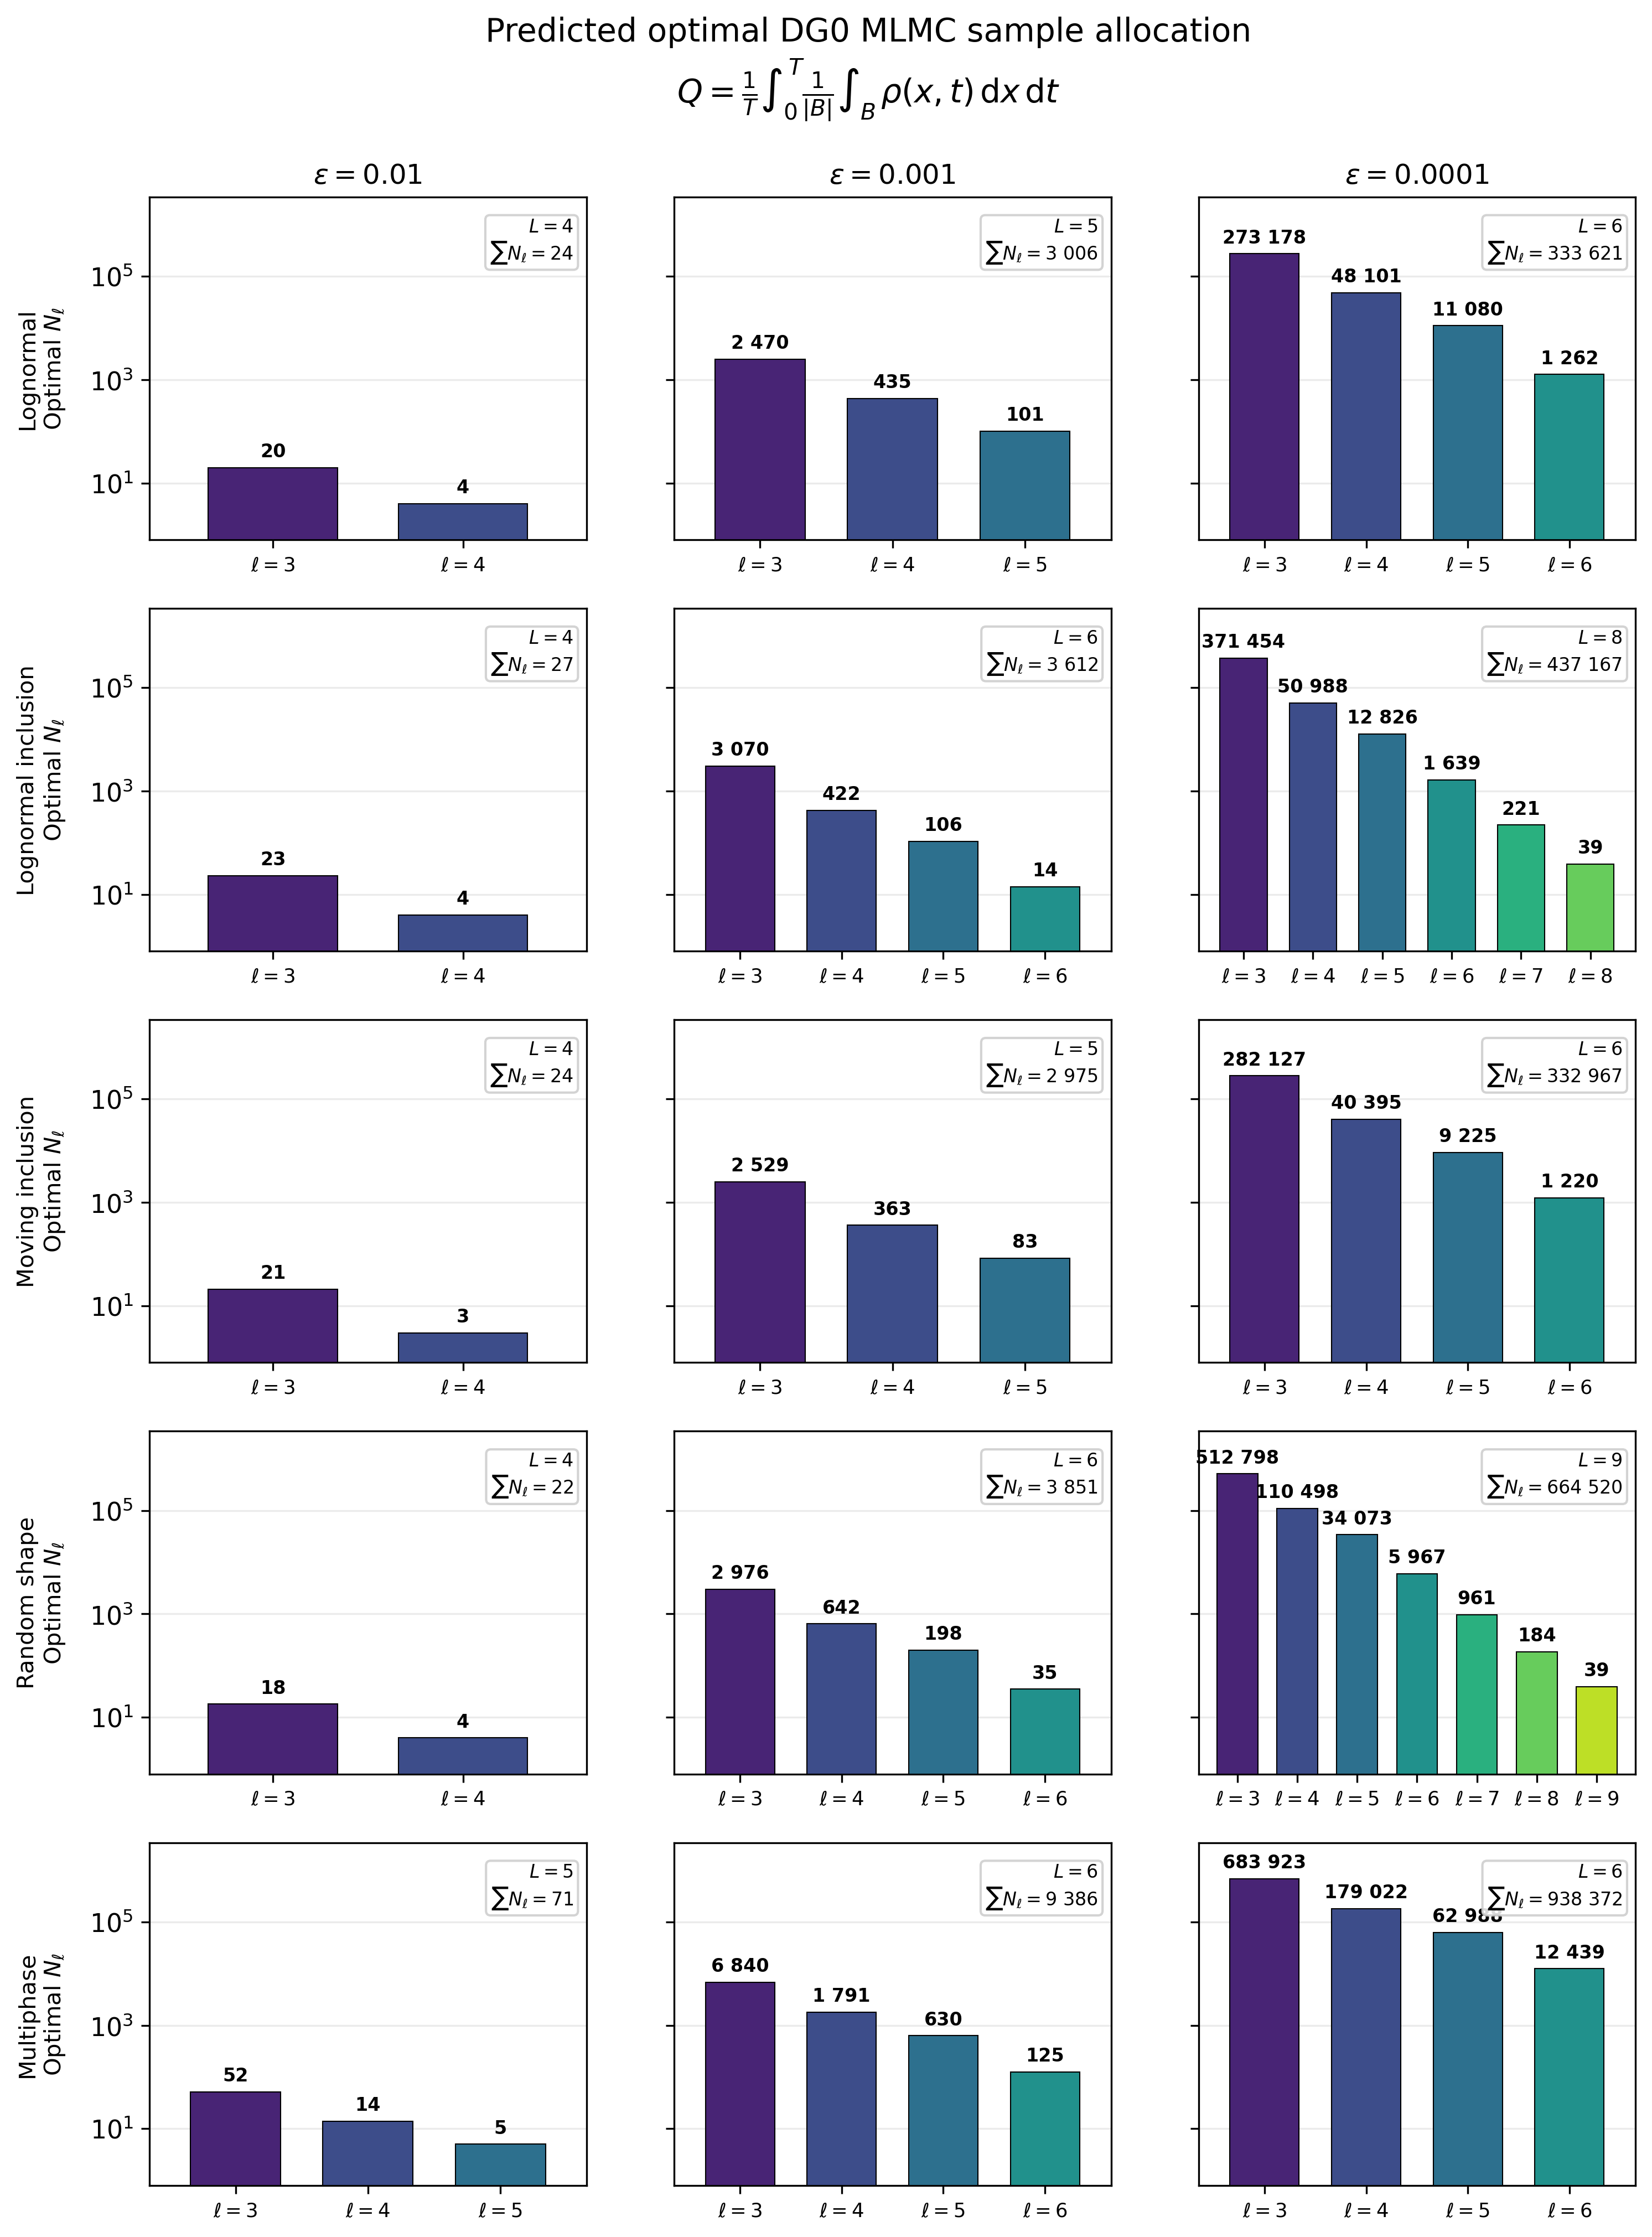

In [5]:
QOI = "mean_c_box_time_average"
DEGREE = 0

EPSILONS = np.array([
    1.0e-2,
    1.0e-3,
    1.0e-4
])

# Allows extrapolation beyond the pilot hierarchy if a tolerance requires it.
MAX_PREDICTED_LEVEL = 12


# =============================================================================
# Pilot statistics for DG0 and the selected QoI
# =============================================================================

delta_column = f"delta_{QOI}"

needed = {
    "field_type",
    "degree_transport",
    "mlmc_level",
    delta_column,
    "fine_runtime",
    "coarse_runtime",
}

missing = sorted(needed.difference(df.columns))
if missing:
    raise KeyError(f"Missing dataframe columns: {missing}")

dg0_data = df[df["degree_transport"] == DEGREE].copy()

pilot_rows = []

for (field_type, level), group in dg0_data.groupby(
    ["field_type", "mlmc_level"]
):
    level = int(level)

    delta = group[delta_column].to_numpy(dtype=float)
    delta = delta[np.isfinite(delta)]

    fine_cost = group["fine_runtime"].to_numpy(dtype=float)
    coarse_cost = group["coarse_runtime"].to_numpy(dtype=float)

    if level == base_level:
        costs = fine_cost
    else:
        costs = fine_cost + coarse_cost

    costs = costs[np.isfinite(costs) & (costs > 0.0)]

    if len(delta) == 0 or len(costs) == 0:
        continue

    pilot_rows.append(
        {
            "field_type": field_type,
            "mlmc_level": level,
            "n_pilot": len(delta),
            "mean_correction": np.mean(delta),
            "abs_mean_correction": abs(np.mean(delta)),
            "variance": (
                np.var(delta, ddof=1)
                if len(delta) > 1
                else np.nan
            ),
            "cost": np.mean(costs),
        }
    )

pilot_summary = (
    pd.DataFrame(pilot_rows)
    .sort_values(["field_type", "mlmc_level"])
    .reset_index(drop=True)
)

if pilot_summary.empty:
    raise ValueError("No valid DG0 pilot data were found.")


# =============================================================================
# Fit rate and prefactor:
#
# weak correction: c_alpha 2^(-alpha*l)
# variance:        c_beta  2^(-beta*l)
# cost:            c_gamma 2^( gamma*l)
# =============================================================================

def fit_level_model(levels, values, decay=True):
    levels = np.asarray(levels, dtype=float)
    values = np.asarray(values, dtype=float)

    valid = (
        np.isfinite(levels)
        & np.isfinite(values)
        & (values > 0.0)
    )

    x = levels[valid]
    y = np.log2(values[valid])

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    slope, intercept = np.polyfit(x, y, 1)

    exponent = -slope if decay else slope
    prefactor = 2.0**intercept

    fitted = intercept + slope * x
    residual = np.sum((y - fitted) ** 2)
    total = np.sum((y - np.mean(y)) ** 2)

    r_squared = (
        1.0 - residual / total
        if total > 0.0
        else np.nan
    )

    return exponent, prefactor, r_squared


# The base level contains Y_base = P_base, not a level correction.
effective_fit_levels = sorted(
    level
    for level in fit_levels
    if level > base_level
)

rate_rows = []

for field_type, field_data in pilot_summary.groupby("field_type"):
    field_data = field_data.sort_values("mlmc_level")

    mask = field_data["mlmc_level"].isin(effective_fit_levels)
    fit_data = field_data[mask]

    alpha, c_alpha, alpha_r2 = fit_level_model(
        fit_data["mlmc_level"],
        fit_data["abs_mean_correction"],
        decay=True,
    )
    beta, c_beta, beta_r2 = fit_level_model(
        fit_data["mlmc_level"],
        fit_data["variance"],
        decay=True,
    )
    gamma, c_gamma, gamma_r2 = fit_level_model(
        fit_data["mlmc_level"],
        fit_data["cost"],
        decay=False,
    )

    rate_rows.append(
        {
            "field_type": field_type,
            "alpha": alpha,
            "c_alpha": c_alpha,
            "alpha_R2": alpha_r2,
            "beta": beta,
            "c_beta": c_beta,
            "beta_R2": beta_r2,
            "gamma": gamma,
            "c_gamma": c_gamma,
            "gamma_R2": gamma_r2,
        }
    )

rate_table = pd.DataFrame(rate_rows)


# =============================================================================
# Select L and calculate optimal N_l
# =============================================================================

configuration_rows = []
overview_rows = []

for _, rates in rate_table.iterrows():
    field_type = rates["field_type"]

    alpha = float(rates["alpha"])
    beta = float(rates["beta"])
    gamma = float(rates["gamma"])

    c_alpha = float(rates["c_alpha"])
    c_beta = float(rates["c_beta"])
    c_gamma = float(rates["c_gamma"])

    if not np.all(np.isfinite([
        alpha, beta, gamma,
        c_alpha, c_beta, c_gamma,
    ])):
        print(f"Skipping {field_type}: invalid fitted model.")
        continue

    if alpha <= 0.0:
        print(
            f"Skipping {field_type}: fitted alpha={alpha:.3f} "
            "does not predict bias decay."
        )
        continue

    field_pilot = (
        pilot_summary[
            pilot_summary["field_type"] == field_type
        ]
        .set_index("mlmc_level")
    )

    observed_levels = set(field_pilot.index.astype(int))

    for epsilon in EPSILONS:
        bias_tolerance = epsilon / np.sqrt(2.0)

        selected_level = None
        selected_bias = None

        # L must be above the base level because Y_base = P_base.
        for candidate_level in range(
            base_level + 1,
            MAX_PREDICTED_LEVEL + 1,
        ):
            predicted_last_correction = (
                c_alpha * 2.0**(-alpha * candidate_level)
            )

            predicted_bias = (
                predicted_last_correction
                / np.expm1(alpha * np.log(2.0))
            )

            if predicted_bias <= bias_tolerance:
                selected_level = candidate_level
                selected_bias = predicted_bias
                break

        if selected_level is None:
            print(
                f"{field_type}, epsilon={epsilon:g}: "
                f"required level exceeds {MAX_PREDICTED_LEVEL}."
            )
            continue

        hierarchy = np.arange(
            base_level,
            selected_level + 1,
            dtype=int,
        )

        variances = []
        costs = []
        sources = []
        pilot_counts = []

        for level in hierarchy:
            if level in observed_levels:
                observed_variance = float(
                    field_pilot.loc[level, "variance"]
                )
                observed_cost = float(
                    field_pilot.loc[level, "cost"]
                )
                n_pilot = int(
                    field_pilot.loc[level, "n_pilot"]
                )
            else:
                observed_variance = np.nan
                observed_cost = np.nan
                n_pilot = 0

            if (
                np.isfinite(observed_variance)
                and observed_variance > 0.0
            ):
                variance = observed_variance
                variance_source = "observed"
            else:
                variance = c_beta * 2.0**(-beta * level)
                variance_source = "fitted"

            if np.isfinite(observed_cost) and observed_cost > 0.0:
                cost = observed_cost
                cost_source = "observed"
            else:
                cost = c_gamma * 2.0**(gamma * level)
                cost_source = "fitted"

            variances.append(max(variance, np.finfo(float).tiny))
            costs.append(max(cost, np.finfo(float).tiny))
            sources.append(f"{variance_source}/{cost_source}")
            pilot_counts.append(n_pilot)

        variances = np.asarray(variances)
        costs = np.asarray(costs)
        pilot_counts = np.asarray(pilot_counts)

        normalization = np.sum(np.sqrt(variances * costs))

        optimal_samples = np.ceil(
            (2.0 / epsilon**2)
            * np.sqrt(variances / costs)
            * normalization
        ).astype(int)

        optimal_samples = np.maximum(optimal_samples, 1)

        predicted_sampling_variance = np.sum(
            variances / optimal_samples
        )
        predicted_work = np.sum(optimal_samples * costs)
        predicted_rmse = np.sqrt(
            predicted_sampling_variance + selected_bias**2
        )

        for (
            level,
            variance,
            cost,
            n_opt,
            n_pilot,
            source,
        ) in zip(
            hierarchy,
            variances,
            costs,
            optimal_samples,
            pilot_counts,
            sources,
        ):
            configuration_rows.append(
                {
                    "qoi": QOI,
                    "degree_transport": DEGREE,
                    "field_type": field_type,
                    "epsilon": epsilon,
                    "mlmc_level": int(level),
                    "L": int(selected_level),
                    "V_l": variance,
                    "C_l": cost,
                    "N_opt": int(n_opt),
                    "N_pilot": int(n_pilot),
                    "N_additional": int(max(n_opt - n_pilot, 0)),
                    "estimate_source": source,
                }
            )

        overview_rows.append(
            {
                "field_type": field_type,
                "epsilon": epsilon,
                "L": selected_level,
                "total_samples": int(optimal_samples.sum()),
                "predicted_bias": selected_bias,
                "sampling_std": np.sqrt(
                    predicted_sampling_variance
                ),
                "predicted_RMSE": predicted_rmse,
                "RMSE_over_epsilon": predicted_rmse / epsilon,
                "predicted_work_seconds": predicted_work,
            }
        )

mlmc_configurations = pd.DataFrame(configuration_rows)
mlmc_overview = pd.DataFrame(overview_rows)

if mlmc_configurations.empty:
    raise ValueError("No valid MLMC configurations were constructed.")



# =============================================================================
# Allocation grid:
# rows    = random-field types
# columns = RMSE tolerances
# bars    = MLMC levels
# =============================================================================

preferred_field_order = [
    "LognormalField",
    "LognormalInclusion",
    "LognormalMovingInclusion",
    "RandomShapeField",
    "MultiphaseField"
]

field_order = [
    field
    for field in preferred_field_order
    if field in mlmc_configurations["field_type"].unique()
]

# Largest tolerance on the left
all_epsilons = np.sort(
    mlmc_configurations["epsilon"].unique()
)[::-1]

all_levels = np.arange(
    base_level,
    int(mlmc_configurations["L"].max()) + 1,
)

level_colors = plt.colormaps["viridis"](
    np.linspace(0.10, 0.90, len(all_levels))
)

level_color = {
    level: color
    for level, color in zip(all_levels, level_colors)
}

global_max_samples = int(
    mlmc_configurations["N_opt"].max()
)

n_rows = len(field_order)
n_columns = len(all_epsilons)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_columns,
    figsize=(3.25 * n_columns + 1.8, 2.75 * n_rows + 1.8),
    sharey=True,
    squeeze=False,
)

for row, field_type in enumerate(field_order):
    field_config = mlmc_configurations[
        mlmc_configurations["field_type"] == field_type
    ]

    for column, epsilon in enumerate(all_epsilons):
        axis = axes[row, column]

        config = field_config[
            np.isclose(
                field_config["epsilon"],
                epsilon,
            )
        ].sort_values("mlmc_level")

        if config.empty:
            axis.set_visible(False)
            continue

        levels = config["mlmc_level"].to_numpy(dtype=int)
        sample_counts = config["N_opt"].to_numpy(dtype=int)

        positions = np.arange(len(levels))
        colors = [level_color[level] for level in levels]

        # A positive bottom keeps N_l=1 visible on the logarithmic axis.
        bars = axis.bar(
            positions,
            sample_counts - 0.8,
            bottom=0.8,
            width=0.68,
            color=colors,
            edgecolor="black",
            linewidth=0.5,
            zorder=3,
        )

        # Exact sample allocation above each bar
        for bar, n_samples in zip(bars, sample_counts):
            axis.annotate(
                f"{n_samples:,}".replace(",", " "),
                xy=(
                    bar.get_x() + 0.5 * bar.get_width(),
                    n_samples,
                ),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="semibold",
            )

        # Unique level label directly under each bar
        axis.set_xticks(positions)
        axis.set_xticklabels(
            [rf"$\ell={level}$" for level in levels],
            fontsize=8.5,
        )

        axis.set_xlim(-0.65, len(levels) - 0.35)
        axis.set_yscale("log")
        axis.set_ylim(
            0.8,
            max(2.0, 5.0 * global_max_samples),
        )

        axis.grid(
            axis="y",
            which="both",
            alpha=0.25,
            zorder=0,
        )

        finest_level = int(config["L"].iloc[0])
        total_samples = int(sample_counts.sum())

        axis.text(
            0.97,
            0.94,
            rf"$L={finest_level}$"
            "\n"
            r"$\sum N_\ell=$" + f"{total_samples:,}".replace(",", " "),
            transform=axis.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox={
                "facecolor": "white",
                "edgecolor": "0.8",
                "alpha": 0.85,
                "boxstyle": "round,pad=0.25",
            },
        )

        # Tolerance headings only once, at the top
        if row == 0:
            axis.set_title(
                rf"$\varepsilon={epsilon:g}$",
                fontsize=12,
                fontweight="semibold",
            )

        # Field-type label at the beginning of each row
        if column == 0:
            field_label = field_name_labels.get(
                field_type,
                field_type,
            )
            axis.set_ylabel(
                field_label + "\n" + r"Optimal $N_\ell$",
                fontsize=10,
                labelpad=10,
            )

fig.suptitle(
    "Predicted optimal DG0 MLMC sample allocation\n"
    + qoi_latex_titles[QOI],
    fontsize=14,
    y=0.95,
)




plt.show()

In [10]:
def extrapolate_fine_statistics(df, field_type, degree, qoi_column, target_level):
    """Predict Var[P_L] and mean fine-sample cost at target_level."""
    available = df[
        (df["field_type"] == field_type)
        & (df["degree_transport"] == degree)
        & (df["mlmc_level"] <= target_level)
    ].copy()

    rows = []
    for level, group in available.groupby("mlmc_level"):
        qoi = group[qoi_column].to_numpy(dtype=float)
        qoi = qoi[np.isfinite(qoi)]

        cost = group["fine_runtime"].to_numpy(dtype=float)
        cost = cost[np.isfinite(cost) & (cost > 0.0)]

        if len(qoi) >= 2 and len(cost) >= 1:
            rows.append(
                {
                    "level": int(level),
                    "variance": np.var(qoi, ddof=1),
                    "mean_cost": np.mean(cost),
                }
            )

    stats = pd.DataFrame(rows).sort_values("level")

    if len(stats) < 2:
        raise ValueError(
            f"Cannot extrapolate fine statistics for {field_type}: "
            "need valid samples on at least two levels."
        )

    levels = stats["level"].to_numpy(dtype=float)

    variance_fit = fitted_over_all_levels(
        levels,
        stats["variance"].to_numpy(dtype=float),
        np.array([target_level]),
    )[0]

    cost_fit = fitted_over_all_levels(
        levels,
        stats["mean_cost"].to_numpy(dtype=float),
        np.array([target_level]),
    )[0]

    return variance_fit, cost_fit

In [11]:
# =============================================================================
# Single-level MC versus MLMC at the same RMSE tolerance
# =============================================================================

fine_qoi_column = f"fine_{QOI}"

if fine_qoi_column not in df.columns:
    raise KeyError(
        f"Required column {fine_qoi_column!r} is missing. "
        "The fine-level QoI is needed to estimate Var[P_L]."
    )

comparison_rows = []

for (field_type, epsilon), config in mlmc_configurations.groupby(
    ["field_type", "epsilon"]
):
    config = config.sort_values("mlmc_level")

    finest_level = int(config["L"].iloc[0])

    # ---------------------------------------------------------------------
    # MLMC predicted work and estimator variance
    # ---------------------------------------------------------------------

    mlmc_work_seconds = np.sum(
        config["N_opt"].to_numpy(dtype=float)
        * config["C_l"].to_numpy(dtype=float)
    )

    mlmc_sampling_variance = np.sum(
        config["V_l"].to_numpy(dtype=float)
        / config["N_opt"].to_numpy(dtype=float)
    )

    overview_selection = mlmc_overview[
        (mlmc_overview["field_type"] == field_type)
        & np.isclose(
            mlmc_overview["epsilon"],
            epsilon,
        )
    ]

    if overview_selection.empty:
        raise ValueError(
            f"No overview row for {field_type}, "
            f"epsilon={epsilon:g}."
        )

    predicted_bias = float(
        overview_selection["predicted_bias"].iloc[0]
    )

    # ---------------------------------------------------------------------
    # Single-level MC statistics on the same finest level L
    # ---------------------------------------------------------------------

    fine_data = df[
        (df["field_type"] == field_type)
        & (df["degree_transport"] == DEGREE)
        & (df["mlmc_level"] == finest_level)
    ]

    fine_qoi = fine_data[fine_qoi_column].to_numpy(dtype=float)
    fine_qoi = fine_qoi[np.isfinite(fine_qoi)]

    fine_cost = fine_data["fine_runtime"].to_numpy(dtype=float)
    fine_cost = fine_cost[
        np.isfinite(fine_cost) & (fine_cost > 0.0)
    ]

    # Use observed P_L statistics where available; otherwise extrapolate them.
    if len(fine_qoi) >= 2 and len(fine_cost) >= 1:
        variance_P_L = np.var(fine_qoi, ddof=1)
        mean_fine_cost = np.mean(fine_cost)
        mc_statistics_source = "observed"
    else:
        variance_P_L, mean_fine_cost = extrapolate_fine_statistics(
            df=df,
            field_type=field_type,
            degree=DEGREE,
            qoi_column=fine_qoi_column,
            target_level=finest_level,
        )
        mc_statistics_source = "extrapolated"

    # Sampling variance <= epsilon^2 / 2
    n_mc = max(
        1,
        int(np.ceil(
            2.0 * variance_P_L / epsilon**2
        )),
    )

    mc_sampling_variance = variance_P_L / n_mc
    mc_work_seconds = n_mc * mean_fine_cost

    mlmc_rmse = np.sqrt(
        predicted_bias**2
        + mlmc_sampling_variance
    )

    mc_rmse = np.sqrt(
        predicted_bias**2
        + mc_sampling_variance
    )

    comparison_rows.append(
        {
            "field_type": field_type,
            "epsilon": float(epsilon),
            "L": finest_level,
            "N_MC": n_mc,
            "N_MLMC_total": int(config["N_opt"].sum()),
            "MC_work_seconds": mc_work_seconds,
            "MLMC_work_seconds": mlmc_work_seconds,
            "MC_work_hours": mc_work_seconds / 3600.0,
            "MLMC_work_hours": mlmc_work_seconds / 3600.0,
            "speedup_MC_over_MLMC": (
                mc_work_seconds / mlmc_work_seconds
            ),
            "predicted_MC_RMSE": mc_rmse,
            "predicted_MLMC_RMSE": mlmc_rmse,
            "MC_RMSE_over_epsilon": mc_rmse / epsilon,
            "MLMC_RMSE_over_epsilon": mlmc_rmse / epsilon,
        }
    )

mc_mlmc_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        ["field_type", "epsilon"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(mc_mlmc_comparison)

,field_type,epsilon,L,N_MC,N_MLMC_total,MC_work_seconds,MLMC_work_seconds,MC_work_hours,MLMC_work_hours,speedup_MC_over_MLMC,predicted_MC_RMSE,predicted_MLMC_RMSE,MC_RMSE_over_epsilon,MLMC_RMSE_over_epsilon
0,LognormalField,0.0100,4,21,24,4.799577e+00,3.574669,0.001333,0.000993,1.342663,0.007466,0.007361,0.746565,0.736110
1,LognormalField,0.0010,5,2398,3006,1.869874e+03,523.286609,0.519409,0.145357,3.573326,0.000756,0.000755,0.756099,0.755495
2,LognormalField,0.0001,6,246944,333621,1.008618e+06,63918.880876,280.171569,17.755245,15.779651,0.000076,0.000076,0.761190,0.761181
3,LognormalInclusion,0.0100,4,21,27,4.818182e+00,3.649006,0.001338,0.001014,1.320409,0.009094,0.008904,0.909389,0.890426
4,LognormalInclusion,0.0010,6,2348,3612,9.815682e+03,626.424272,2.726578,0.174007,15.669383,0.000861,0.000860,0.860943,0.859814
5,LognormalInclusion,0.0001,8,236783,437167,4.922120e+07,91615.702689,13672.555108,25.448806,537.257227,0.000082,0.000082,0.818328,0.817485
6,LognormalMovingInclusion,0.0100,4,21,24,4.760807e+00,3.167216,0.001322,0.000880,1.503152,0.007211,0.007317,0.721101,0.731661
7,LognormalMovingInclusion,0.0010,5,2251,2975,1.761827e+03,465.769025,0.489396,0.129380,3.782619,0.000731,0.000731,0.731137,0.730709
8,LognormalMovingInclusion,0.0001,6,229889,332967,9.520361e+05,57899.324309,264.454462,16.083146,16.442956,0.000073,0.000073,0.727549,0.727520
9,MultiphaseField,0.0100,5,45,71,3.571996e+01,15.074524,0.009922,0.004187,2.369558,0.007062,0.007031,0.706181,0.703084


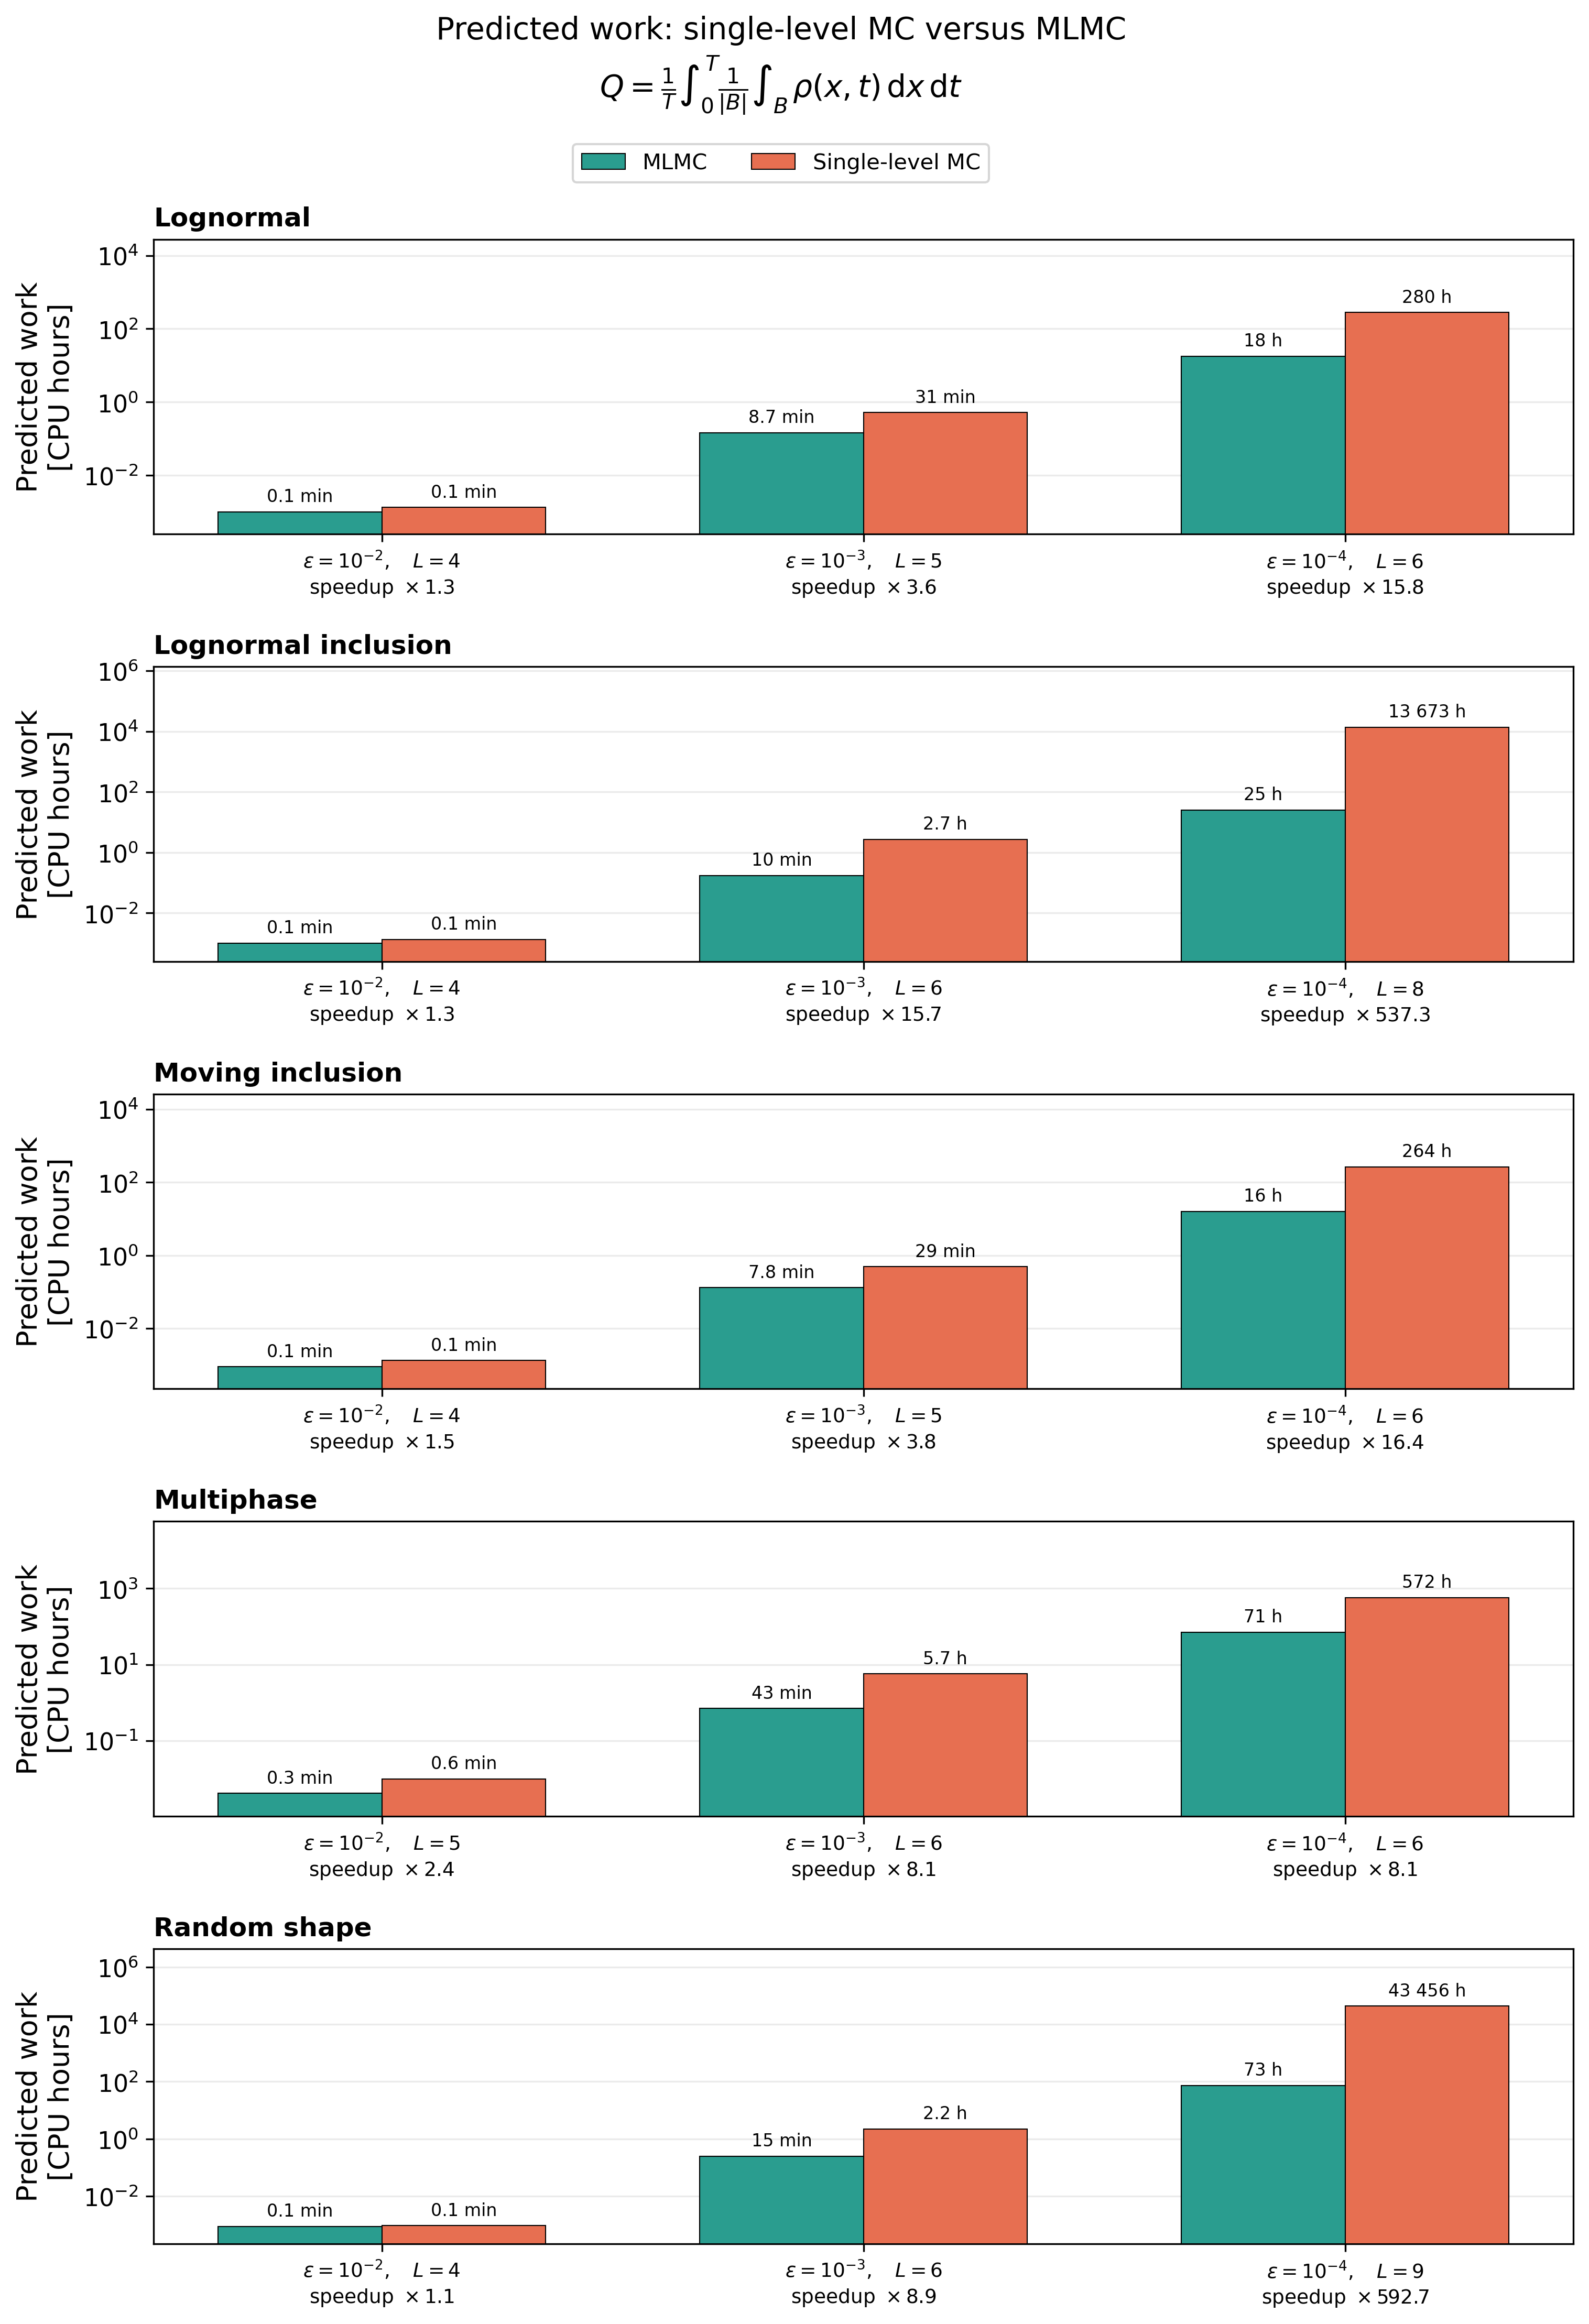

In [12]:
# =============================================================================
# Cost comparison plot
# =============================================================================

preferred_field_order = [
    "LognormalField",
    "LognormalInclusion",
    "LognormalMovingInclusion",
    "MultiphaseField",
    "RandomShapeField",
]

field_order = [
    field
    for field in preferred_field_order
    if field in mc_mlmc_comparison["field_type"].unique()
]


def format_work(hours):
    """Format work stored in hours, using minutes below one hour."""

    if hours < 1.0:
        minutes = 60.0 * hours

        if minutes < 10.0:
            text = f"{minutes:,.1f}"
        else:
            text = f"{minutes:,.0f}"

        return text.replace(",", " ") + " min"

    if hours < 10.0:
        text = f"{hours:,.1f}"
    else:
        text = f"{hours:,.0f}"

    return text.replace(",", " ") + " h"

def epsilon_latex(epsilon):
    """Return epsilon in LaTeX scientific notation."""
    epsilon = float(epsilon)

    if epsilon <= 0.0:
        return f"{epsilon:g}"

    exponent = int(np.floor(np.log10(epsilon)))
    mantissa = epsilon / 10.0**exponent

    if np.isclose(mantissa, 1.0):
        return rf"10^{{{exponent}}}"

    return rf"{mantissa:g}\times 10^{{{exponent}}}"

fig, axes = plt.subplots(
    len(field_order),
    1,
    figsize=(10.5, 2.7 * len(field_order) + 1.5),
    squeeze=False,
)

axes = axes[:, 0]

bar_width = 0.34

for axis, field_type in zip(axes, field_order):
    field_data = (
        mc_mlmc_comparison[
            mc_mlmc_comparison["field_type"] == field_type
        ]
        .sort_values("epsilon", ascending=False)
        .reset_index(drop=True)
    )

    x = np.arange(len(field_data))

    mlmc_work = field_data[
        "MLMC_work_hours"
    ].to_numpy(dtype=float)

    mc_work = field_data[
        "MC_work_hours"
    ].to_numpy(dtype=float)

    minimum_work = min(
        mlmc_work.min(),
        mc_work.min(),
    )
    maximum_work = max(
        mlmc_work.max(),
        mc_work.max(),
    ) 

    # Positive baseline for logarithmic bars
    lower_limit = max(
        minimum_work / 4.0,
        np.finfo(float).tiny,
    )

    mlmc_bars = axis.bar(
        x - bar_width / 2,
        mlmc_work - lower_limit,
        bottom=lower_limit,
        width=bar_width,
        color="#2a9d8f",
        edgecolor="black",
        linewidth=0.5,
        label="MLMC",
        zorder=3,
    )

    mc_bars = axis.bar(
        x + bar_width / 2,
        mc_work - lower_limit,
        bottom=lower_limit,
        width=bar_width,
        color="#e76f51",
        edgecolor="black",
        linewidth=0.5,
        label="Single-level MC",
        zorder=3,
    )

    # Work labels
    for bars, values in [
        (mlmc_bars, mlmc_work),
        (mc_bars, mc_work),
    ]:
        for bar, value in zip(bars, values):
            axis.annotate(
                format_work(value),
                xy=(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                ),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
                annotation_clip=False,
            )

    tick_labels = []

    for row in field_data.itertuples():
        epsilon_text = epsilon_latex(row.epsilon)
        speedup = row.speedup_MC_over_MLMC

        tick_labels.append(
            rf"$\varepsilon={epsilon_text},\quad L={int(row.L)}$"
            "\n"
            rf"$\mathrm{{speedup}}\ \times {speedup:.1f}$"
        )

    axis.set_xticks(x)
    axis.set_xticklabels(
        tick_labels,
        fontsize=9,
        linespacing=1.35,
    )


    axis.set_yscale("log")
    axis.set_ylim(
        lower_limit,
        100.0 * maximum_work,
    )

    axis.set_ylabel("Predicted work\n[CPU hours]")

    axis.set_title(
        field_name_labels.get(field_type, field_type),
        loc="left",
        fontsize=12,
        fontweight="semibold",
    )

    axis.grid(
        axis="y",
        which="both",
        alpha=0.25,
        zorder=0,
    )


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.945),
    frameon=True,
    fontsize=10
)

fig.suptitle(
    "Predicted work: single-level MC versus MLMC\n"
    + qoi_latex_titles[QOI],
    fontsize=14,
    y=0.995,
)

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    bottom=0.05,
    top=0.90,
    hspace=0.45,
)

plt.show()

In [13]:
# =============================================================================
# Summary tables: single-level MC versus MLMC
# =============================================================================

from IPython.display import display, Markdown


def format_integer(value):
    return f"{int(value):,}".replace(",", " ")


def format_work(hours):
    """Format work stored in hours."""
    hours = float(hours)

    if hours < 1.0:
        minutes = 60.0 * hours

        if minutes < 10.0:
            text = f"{minutes:,.1f}"
        else:
            text = f"{minutes:,.0f}"

        return text.replace(",", " ") + " min"

    if hours < 10.0:
        text = f"{hours:,.1f}"
    else:
        text = f"{hours:,.0f}"

    return text.replace(",", " ") + " h"


def epsilon_latex(epsilon):
    epsilon = float(epsilon)

    exponent = int(np.floor(np.log10(epsilon)))
    mantissa = epsilon / 10.0**exponent

    if np.isclose(mantissa, 1.0):
        return rf"10^{{{exponent}}}"

    return rf"{mantissa:g}\times 10^{{{exponent}}}"


preferred_field_order = [
    "LognormalField",
    "LognormalInclusion",
    "LognormalMovingInclusion",
    "RandomShapeField",
    "MultiphaseField",

]

field_order = [
    field
    for field in preferred_field_order
    if field in mc_mlmc_comparison["field_type"].unique()
]

all_epsilons = np.sort(
    mc_mlmc_comparison["epsilon"].unique()
)[::-1]

comparison_tables = {}

for epsilon in all_epsilons:
    epsilon_comparison = mc_mlmc_comparison[
        np.isclose(
            mc_mlmc_comparison["epsilon"],
            epsilon,
        )
    ]

    epsilon_configurations = mlmc_configurations[
        np.isclose(
            mlmc_configurations["epsilon"],
            epsilon,
        )
    ]

    # Include every level required by at least one field type
    required_levels = np.sort(
        epsilon_configurations["mlmc_level"]
        .unique()
        .astype(int)
    )

    table_rows = []

    for field_type in field_order:
        comparison = epsilon_comparison[
            epsilon_comparison["field_type"] == field_type
        ]

        configuration = epsilon_configurations[
            epsilon_configurations["field_type"] == field_type
        ].sort_values("mlmc_level")

        if comparison.empty or configuration.empty:
            continue

        comparison = comparison.iloc[0]

        samples_by_level = {
            int(row.mlmc_level): int(row.N_opt)
            for row in configuration.itertuples()
        }

        row = {
            "Field type": field_name_labels.get(
                field_type,
                field_type,
            ),
            "Finest level L": int(comparison["L"]),
            "MC evaluations at L": format_integer(
                comparison["N_MC"]
            ),
            "MC work": format_work(
                comparison["MC_work_hours"]
            ),
        }

        for level in required_levels:
            if level in samples_by_level:
                row[rf"MLMC N{level}"] = format_integer(
                    samples_by_level[level]
                )
            else:
                row[rf"MLMC N{level}"] = "—"

        row["MLMC work"] = format_work(
            comparison["MLMC_work_hours"]
        )
        row["Speedup"] = (
            "× "
            + format_integer(
                round(
                    comparison["speedup_MC_over_MLMC"]
                )
            )
            if comparison["speedup_MC_over_MLMC"] >= 100
            else f"× {comparison['speedup_MC_over_MLMC']:.1f}"
        )

        table_rows.append(row)

    table = pd.DataFrame(table_rows)

    comparison_tables[float(epsilon)] = table

    display(
        Markdown(
            rf"### $\varepsilon={epsilon_latex(epsilon)}$"
        )
    )

    styled_table = (
        table.style
        .hide(axis="index")
        .set_properties(
            **{
                "text-align": "center",
                "white-space": "nowrap",
            }
        )
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "center"),
                        ("font-weight", "bold"),
                        ("white-space", "nowrap"),
                    ],
                },
                {
                    "selector": "td:first-child",
                    "props": [
                        ("text-align", "left"),
                        ("font-weight", "semibold"),
                    ],
                },
            ]
        )
    )

    display(styled_table)


### $\varepsilon=10^{-2}$

Field type,Finest level L,MC evaluations at L,MC work,MLMC N3,MLMC N4,MLMC N5,MLMC work,Speedup
Lognormal,4,21,0.1 min,20,4,—,0.1 min,× 1.3
Lognormal inclusion,4,21,0.1 min,23,4,—,0.1 min,× 1.3
Moving inclusion,4,21,0.1 min,21,3,—,0.1 min,× 1.5
Random shape,4,15,0.1 min,18,4,—,0.1 min,× 1.1
Multiphase,5,45,0.6 min,52,14,5,0.3 min,× 2.4


### $\varepsilon=10^{-3}$

Field type,Finest level L,MC evaluations at L,MC work,MLMC N3,MLMC N4,MLMC N5,MLMC N6,MLMC work,Speedup
Lognormal,5,2 398,31 min,2 470,435,101,—,8.7 min,× 3.6
Lognormal inclusion,6,2 348,2.7 h,3 070,422,106,14,10 min,× 15.7
Moving inclusion,5,2 251,29 min,2 529,363,83,—,7.8 min,× 3.8
Random shape,6,1 924,2.2 h,2 976,642,198,35,15 min,× 8.9
Multiphase,6,4 967,5.7 h,6 840,1 791,630,125,43 min,× 8.1


### $\varepsilon=10^{-4}$

Field type,Finest level L,MC evaluations at L,MC work,MLMC N3,MLMC N4,MLMC N5,MLMC N6,MLMC N7,MLMC N8,MLMC N9,MLMC work,Speedup
Lognormal,6,246 944,280 h,273 178,48 101,11 080,1 262,—,—,—,18 h,× 15.8
Lognormal inclusion,8,236 783,13 673 h,371 454,50 988,12 826,1 639,221,39,—,25 h,× 537
Moving inclusion,6,229 889,264 h,282 127,40 395,9 225,1 220,—,—,—,16 h,× 16.4
Random shape,9,253 364,43 456 h,512 798,110 498,34 073,5 967,961,184,39,73 h,× 593
Multiphase,6,496 694,572 h,683 923,179 022,62 988,12 439,—,—,—,71 h,× 8.1
